<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/DL/Autoencoders/Autoenoder_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import the MNIST dataset from Keras
from tensorflow.keras.datasets import mnist
# Import Model for creating the autoencoder model
from tensorflow.keras.models import Model
# Import Input and Dense layers for building the neural network
from tensorflow.keras.layers import Input , Dense
# Import Adam optimizer
from tensorflow.keras.optimizers import Adam

In [2]:
# Load the MNIST dataset. x_train and x_test contain image data.
# We only need the image data for unsupervised learning, so we discard the labels (_).
(x_train , _) , (x_test , _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Convert image pixel values to float32 and normalize them to the range [0, 1].
# This is a common preprocessing step for neural networks.
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [4]:
# Reshape the 28x28 pixel images into a 1D vector of 784 pixels.
# This is necessary because the Dense layers expect a 1D input.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [5]:
# Define the input dimension (number of features for each image, 28*28 = 784)
input_dim = 784
# Define the dimension of the encoded (latent space) representation
encoding_dim = 32

In [6]:
# Define the input layer of the autoencoder.
# It takes a 1D array of size `input_dim` (784 pixels) for each image.
input_img = Input(shape=(input_dim,))

In [7]:
# ENCODER LAYERS
# First encoding layer: A Dense layer with 128 units and ReLU activation.
enoded = Dense(128 , activation='relu')(input_img)
# Second encoding layer: A Dense layer with 64 units and ReLU activation.
encoded = Dense(64 , activation='relu')(enoded)
# Third (bottleneck) encoding layer: A Dense layer with `encoding_dim` (32) units and ReLU activation.
# This layer represents the compressed, latent space representation of the input.
encoded = Dense(encoding_dim , activation='relu')(encoded)

In [8]:
# DECODER LAYERS
# First decoding layer: A Dense layer with 64 units and ReLU activation.
decoded = Dense(64 , activation='relu')(encoded)
# Second decoding layer: A Dense layer with 128 units and ReLU activation.
decoded = Dense(128 , activation='relu')(decoded)
# Output decoding layer: A Dense layer with `input_dim` (784) units and Sigmoid activation.
# Sigmoid is used because the output pixels are normalized between 0 and 1.
decoded = Dense(input_dim , activation='sigmoid')(decoded)

In [9]:
# Create the autoencoder model.
# It takes the `input_img` and outputs the `decoded` image.
autoencoder = Model(input_img , decoded)
# Compile the autoencoder model.
# 'adam' optimizer is used for training.
# 'binary_crossentropy' is used as the loss function, suitable for pixel-wise reconstruction with sigmoid output.
autoencoder.compile(optimizer='adam' , loss='binary_crossentropy')

In [10]:
# Train the autoencoder model.
# x_train is used as both input and target (autoencoder learns to reconstruct its input).
# epochs: Number of training iterations.
# batch_size: Number of samples per gradient update.
# shuffle: Shuffles the training data before each epoch.
# validation_data: Data to evaluate the loss and any model metrics at the end of each epoch.
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.2477 - val_loss: 0.1675
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1514 - val_loss: 0.1388
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1320 - val_loss: 0.1237
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1205 - val_loss: 0.1159
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1147 - val_loss: 0.1114
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1108 - val_loss: 0.1082
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1079 - val_loss: 0.1062
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1057 - val_loss: 0.1032
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1034 - val_loss: 0.1015
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1015 - val_loss: 0.0996
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1001 - val_loss: 0.0983
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# Create an encoder model that takes the input image and outputs the `encoded` (latent space) representation.
# This model can be used to get the compressed features of new images.
encoder = Model(input_img, encoded)

In [12]:
# Use the encoder model to predict the encoded representations of the test images.
encoded_imgs = encoder.predict(x_test)

# Print the shape of the encoded images, which should be (number_of_test_images, encoding_dim).
print(encoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 32)


In [13]:
# Use the full autoencoder model to predict the decoded (reconstructed) images from the test set.
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


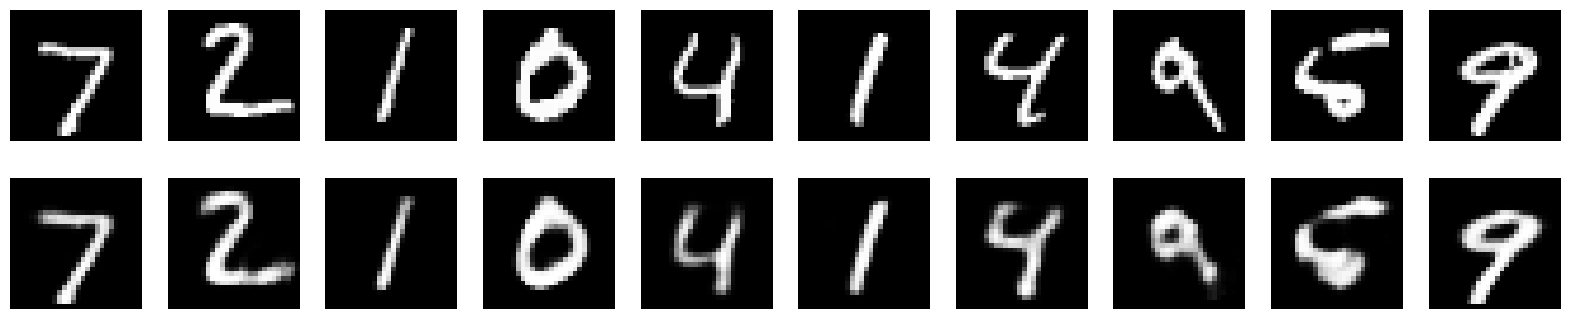

In [14]:
# Display a comparison of original and reconstructed images.
# n: Number of images to display.
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Display Original Image
    # Create a subplot for the original image.
    ax = plt.subplot(2,n,i+1)
    # Reshape the 1D image vector back to 28x28 and display it.
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    # Turn off axis ticks and labels.
    plt.axis("off")

    # Display Reconstruction Image
    # Create a subplot for the reconstructed image.
    ax = plt.subplot(2,n,i+1+n)
    # Reshape the 1D reconstructed image vector back to 28x28 and display it.
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    # Turn off axis ticks and labels.
    plt.axis("off")

# Show the plot containing original and reconstructed images.
plt.show()